In [146]:
!pip install pandas numpy matplotlib seaborn spacy scikit-learn

In [147]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns 
import spacy 
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline

In [125]:
data = pd.read_csv('train.txt', delimiter=";", header=None, names=["Text","Emotion"])

In [126]:
data.head(30)

,Text,Emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
5,ive been feeling a little burdened lately wasn...,sadness
6,ive been taking or milligrams or times recomme...,surprise
7,i feel as confused about life as a teenager or...,fear
8,i have been with petronas for years i feel tha...,joy
9,i feel romantic too,love


In [143]:
data.isnull().sum()

Text       0
Emotion    0
dtype: int64

In [127]:
data.shape

(16000, 2)

In [128]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Text     16000 non-null  object
 1   Emotion  16000 non-null  object
dtypes: object(2)
memory usage: 250.1+ KB


In [129]:
def pre_process_emotion(df):
    data["Emotion"] = df["Emotion"].map({'sadness':0, 'anger':1, 'joy':2, 'surprise':3, 'fear':4, 'love':5})
    return df 


In [151]:
data = pre_process_emotion(data)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Text     16000 non-null  object 
 1   Emotion  0 non-null      float64
dtypes: float64(1), object(1)
memory usage: 250.1+ KB


In [152]:
nlp = spacy.load("en_core_web_sm")
data = data.dropna(subset=["Text"])
data['Text'] = data['Text'].astype(str)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Text     16000 non-null  object 
 1   Emotion  0 non-null      float64
dtypes: float64(1), object(1)
memory usage: 250.1+ KB


In [153]:
nlp = spacy.load("en_core_web_sm")
data = data.dropna(subset=["Text"])
data['Text'] = data['Text'].astype(str)
def pre_process_text(text):

    doc = nlp(text)
    filtered_tokens = []
    for token in doc:
        if token.is_stop or token.is_punct:
            continue
        filtered_tokens.append(token.lemma_)
    return " ".join(filtered_tokens)
    
data['Text'] = data['Text'].apply(pre_process_text)

In [154]:
data.head()

,Text,Emotion
0,feel humiliated,NaN
1,feel hopeless damned hopeful care awake,NaN
2,m grab minute post feel greedy wrong,NaN
3,feel nostalgic fireplace know property,NaN
4,feel grouchy,NaN


In [135]:
clf = Pipeline([
    ('vectorizer_tfidf',TfidfVectorizer()),
    ('random_forest', RandomForestClassifier())
])

X = data.Text.astype(str)
y = data.Emotion

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))
report = classification_report(y_test, y_pred, output_dict=True)

              precision    recall  f1-score   support

           0       0.90      0.87      0.89       914
           1       0.86      0.85      0.85       431
           2       0.83      0.91      0.87      1093
           3       0.75      0.70      0.72       115
           4       0.83      0.83      0.83       382
           5       0.81      0.66      0.73       265

    accuracy                           0.85      3200
   macro avg       0.83      0.80      0.82      3200
weighted avg       0.85      0.85      0.85      3200



In [136]:
df_report= pd.DataFrame(report).transpose()
df_classes = df_report.iloc[:6][['precision', 'recall', 'f1-score']]


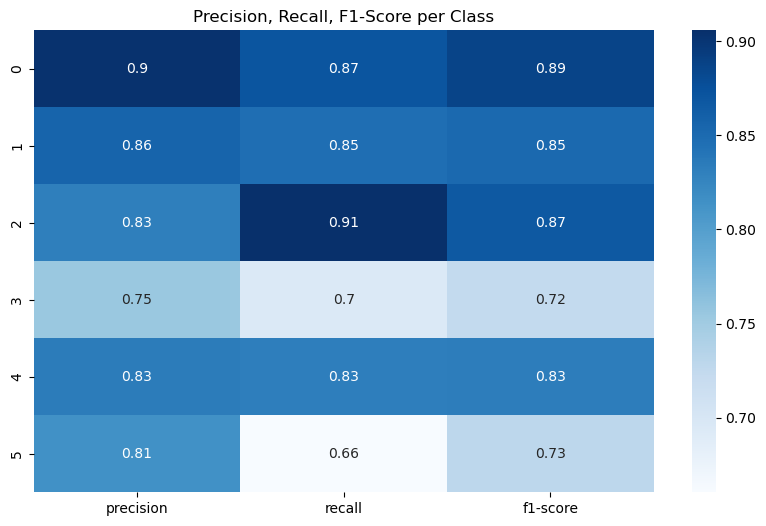

In [137]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_classes, annot=True, cmap='Blues')
plt.title('Precision, Recall, F1-Score per Class')
plt.show()

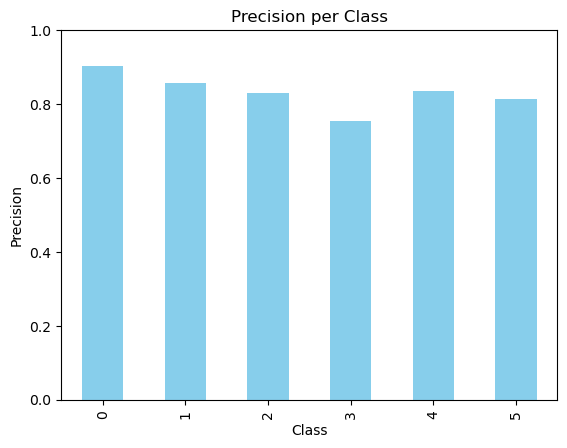

In [141]:
df_classes['precision'].plot(kind='bar', title='Precision per Class', color='skyblue')
plt.ylabel('Precision')
plt.xlabel('Class')
plt.ylim(0, 1)
plt.show()

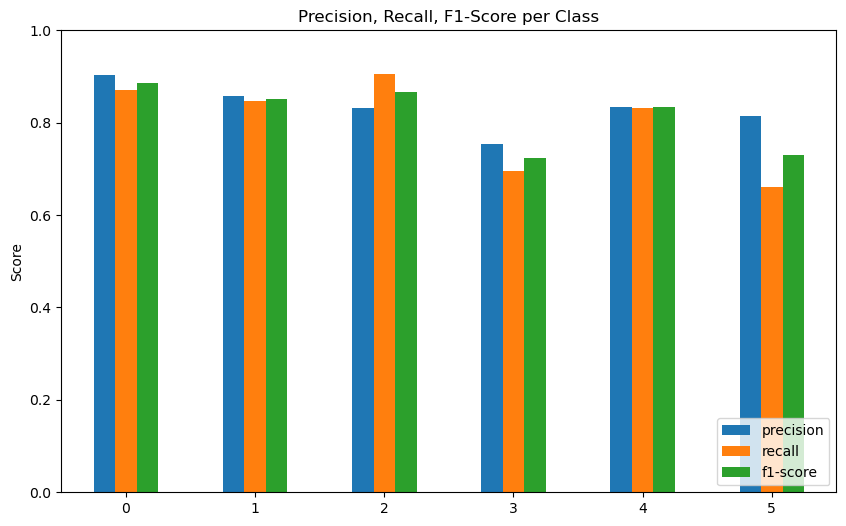

In [140]:
df_classes.plot(kind='bar', figsize=(10,6))
plt.title('Precision, Recall, F1-Score per Class')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show() 